In [1]:
# cell-01 – Importy

import subprocess
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# cell-02

path = "/home/marcin/kod/flir-test/data-flir-test/FLIR0147.jpg"
result = subprocess.check_output(["exiftool", "-EmbeddedImage", "-b", path]).decode(errors='ignore')
print("RGB dostępne" if result else "Brak RGB")

Brak RGB


    1 output files created
Znalezione parametry: ['R1', 'B', 'F', 'O', 'R2', 'DigitalZoomRatio', 'Emissivity', 'ReflectedApparentTemperature', 'AtmosphericTemperature']
Emisyjność: 0.95, T_odbicia: 20.0°C, T_atm: 23.0°C


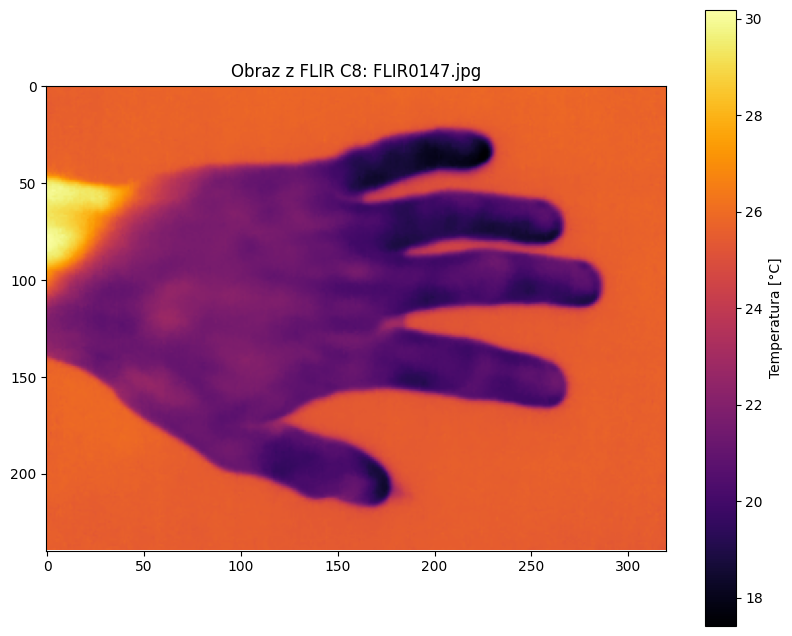

In [3]:
# cell-03

def raw_from_temp(T_celsius, R1, R2, B, F, O):
    """Konwertuje temperaturę [°C] na surowy sygnał RAW (odwrotność wzoru Plancka)."""
    T_K = T_celsius + 273.15
    return R1 / (R2 * (np.exp(B / T_K) - F)) - O


def get_flir_data_robust(file_path):
    try:
        # 1. Tworzymy TIFF (to już wiemy, że działa i naprawia geometrię)
        generated_tiff = file_path.replace(".jpg", ".tiff")
        subprocess.run(["exiftool", "-b", "-RawThermalImage", file_path, "-w!", "tiff"], check=True)

        # Wczytujemy macierz RAW
        raw_matrix = plt.imread(generated_tiff).astype(float)

        # 2. Pobieramy metadane
        cmd_meta = ["exiftool", "-s", "-Planck*", "-*R1", "-*R2", "-*B", "-*F", "-*O",
                    "-Emissivity", "-ReflectedApparentTemperature", "-AtmosphericTemperature",
                    file_path]
        meta_out = subprocess.check_output(cmd_meta).decode()

        params = {}
        for line in meta_out.split('\n'):
            if ':' in line:
                key, val = line.split(':', 1)
                clean_key = key.strip().replace('Planck', '')
                try:
                    params[clean_key] = float(val.strip().split()[0])
                except (ValueError, IndexError):
                    continue

        print(f"Znalezione parametry: {list(params.keys())}")

        # 3. Sprawdzamy czy mamy komplet stałych Plancka
        required = ['R1', 'R2', 'B', 'F', 'O']
        if all(k in params for k in required):
            R1, R2, B, F, O = params['R1'], params['R2'], params['B'], params['F'], params['O']

            # Pobieramy parametry środowiskowe
            emissivity = params.get('Emissivity', 1.0)
            T_refl     = params.get('ReflectedApparentTemperature', 20.0)
            T_atm      = params.get('AtmosphericTemperature', 23.0)

            print(f"Emisyjność: {emissivity}, T_odbicia: {T_refl}°C, T_atm: {T_atm}°C")

            # Przeliczamy temperatury referencyjne na sygnał RAW
            S_refl = raw_from_temp(T_refl, R1, R2, B, F, O)
            S_atm  = raw_from_temp(T_atm,  R1, R2, B, F, O)

            # Odejmujemy wkład odbitego promieniowania (τ ≈ 1.0 dla < ~5m)
            S_obj = (raw_matrix - (1 - emissivity) * S_refl) / emissivity

            # Przeliczamy na temperaturę [°C]
            denominator = np.clip(R2 * (S_obj + O), 1e-10, None)
            temp_c = B / np.log(R1 / denominator + F) - 273.15

        else:
            print("⚠️ Brak stałych Plancka w metadanych! Wyświetlam surowy sygnał RAW.")
            temp_c = raw_matrix

        # Sprzątanie
        if os.path.exists(generated_tiff):
            os.remove(generated_tiff)
        
        global debug_raw
        debug_raw = raw_matrix.copy()    

        return temp_c

    except Exception as e:
        print(f"Błąd: {e}")
        return None


# --- URUCHOMIENIE ---
data = get_flir_data_robust(path)
if data is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap='inferno')
    plt.colorbar(label='Temperatura [°C]')
    plt.title(f"Obraz z FLIR C8: {os.path.basename(path)}")
    plt.show()

    1 output files created
Znalezione parametry: ['R1', 'B', 'F', 'O', 'R2', 'DigitalZoomRatio', 'Emissivity', 'ReflectedApparentTemperature', 'AtmosphericTemperature']
Emisyjność: 0.95, T_odbicia: 20.0°C, T_atm: 23.0°C


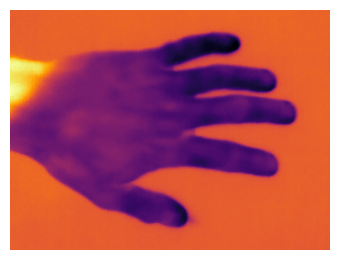

In [4]:
# cell-04
data = get_flir_data_robust(path)

if data is not None:
    # Ustawiamy figurę tak, aby nie rysowała tła ramki
    # 3.2, 2.4 da dokładnie 320×240 px — czyli 1:1 z detektorem IR
    fig = plt.figure(frameon=False, figsize=(3.2, 2.4), dpi=100)
    
    # Dodajemy osie zajmujące 100% powierzchni figury [lewo, dół, szerokość, wysokość]
    # To kluczowy krok, który eliminuje białą obwódkę (padding)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    
    # Wyświetlamy obraz bez dodatkowych marginesów
    ax.imshow(data, cmap='inferno', aspect='auto')
    
    plt.show()